## Settings and imports

In [1]:
import numpy as np
import pandas as pd
import os
import torch
import matplotlib.pyplot as plt
import string
from torch import nn
from torch.utils.data import Dataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
import random

In [2]:
object_name = 'Documents_XVIII_century' # Books / Documents_XVIII_century

In [3]:
if object_name == 'Books':
    real_or_simulated = 'real' #simulated / real / all
    augmentation = False
    augmentation_weights = [0.9, 0.1]
    proportion_of_augmented = 0.25

keep_sample_together = False #Should all 15 slices from the same sample go together to the same set (train/test)?
if keep_sample_together:
    sample_together = 'sample_together'
else:
    sample_together = 'sample_split'
    
preprocessing_method = 'logarithm' # normalization / logarithm

columns_to_keep_inks = {
                        'Books': [
                                                 'Al_inks',
                                                 'S_inks',
                                                 'Cr_inks',
                                                 'Mn_inks',
                                                 'Co_inks',
                                                 'Cu_inks',
                                                 'Zn_inks',
                                                 'Pb_inks'],
    
                        'Documents_XVIII_century' : [
                                                 'Al_inks',
                                                 'S_inks',
                                                 'Cr_inks',
                                                 'Mn_inks',
                                                 'Co_inks',
                                                 'Cu_inks',
                                                 'Zn_inks',
                                                 'Pb_inks'
                                                            ],
    
                        'Konstytucja' : [
                                                 'Al',
                                                 'S',
                                                 'Cr',
                                                 'Mn',
                                                 'Co',
                                                 'Cu',
                                                 'Zn',
                                                 'Pb'
                                                            ]
    
                        }

columns_to_keep_inds = { 
                        'Books' : [
                            
                                                 'Al_inds',
                                                 'S_inds',
                                                 'Cr_inds',
                                                 'Mn_inds',
                                                 'Co_inds',
                                                 'Cu_inds',
                                                 'Zn_inds',
                                                 'Pb_inds'],
    
                        'Documents_XVIII_century' : [
                                                 'Al_inds',
                                                 'S_inds',
                                                 'Cr_inds',
                                                 'Mn_inds',
                                                 'Co_inds',
                                                 'Cu_inds',
                                                 'Zn_inds',
                                                 'Pb_inds'
                                                        ],
                        'Konstytucja' : []
    
                        }

In [4]:
data_path = {'Books' : '../data/DANE.xlsx',
             'Documents_XVIII_century' : '../data/Lipiec_2024.xlsx',
             'Konstytucja' : '../data/Lipiec_2024.xlsx'}

results_path = {'Books' : '../results/Books/',
                'Documents_XVIII_century' : '../results/Documents_XVIII_century/',
                'Konstytucja' : '../results/Konstytucja/'}

figures_path = {'Books' : '../results/visualisations/Books/',
                'Documents_XVIII_century' : '../results/visualisations/Documents_XVIII_century/',
                'Konstytucja': '../results/visualisations/Konstytucja/'}

models_path = {'Books' : '../models/Books/',
                'Documents_XVIII_century' : '../models/Documents_XVIII_century/',
                'Konstytucja' : '../models/Konstytucja/'}

1) próbki razem + trzymanie jakiegoś id
2) czyszczenie danych
3) train-test split
4) augmentacja
5) normalizacja
6) ocena jakości

## Loading the data

In [5]:
df = pd.ExcelFile(data_path[object_name])

if object_name == 'Books':
    if real_or_simulated == 'simulated':
        inks_df = df.parse('a.', header=0, index_col=0, usecols=list)[:1425] #inKs
        inds_df = df.parse('i.', header=0, index_col=0, usecols=list)[:1425]  #inDs
    elif real_or_simulated == 'real':
        inks_df = df.parse('a.', header=0, index_col=0, usecols=list)[1425:] #inKs
        inds_df = df.parse('i.', header=0, index_col=0, usecols=list)[1425:]  #inDs
    elif real_or_simulated == 'all':
        inks_df = df.parse('a.', header=0, index_col=0, usecols=list) #inKs
        inds_df = df.parse('i.', header=0, index_col=0, usecols=list) #inDs

elif object_name == 'Documents_XVIII_century':
    inks_df = df.parse('Arkusz1', header=0, usecols=range(2,29), skiprows=range(3931, 4742))
    inds_df = df.parse('Arkusz1', header=0, usecols=range(32,59), skiprows=range(3931, 4742))
    inds_df.columns = inks_df.columns

## Preprocessing

### Joining corresponding samples from inds and inks into one table

In [6]:
inks_df = inks_df.reset_index(drop=False)
inds_df = inds_df.reset_index(drop=False)
inDKs_df = inds_df.join(inks_df, how='inner', rsuffix='_inks', lsuffix='_inds')

In [7]:
# with pd.option_context("display.max_rows", inDKs_df.shape[0]):
#     display(inDKs_df[['nazwa próbki_inds', 'nazwa próbki_inks']][
#                 (inDKs_df['nazwa próbki_inds'].apply(
#                         lambda x: x[:4]) != inDKs_df['nazwa próbki_inks'].apply(
#                                         lambda x: x[:4]))
#                                                         ])

### Keeping track of the records from the same sample

In [8]:
inDKs_df['Sample_id'] = np.repeat(range(int(inDKs_df.shape[0]/15)), 15, axis=0)

In [9]:
# with pd.option_context("display.max_rows", inDKs_df.shape[0]):
#     display(inDKs_df)

### Removing some data

1. Let's keep only columns that we need.

To reduce the set of used elements run cell below. Then, instead of predicting 29 numbers, we will predict only 8. We will also use only 8 numbers as input.

In [10]:
inDKs_df = inDKs_df[columns_to_keep_inks[object_name] + columns_to_keep_inds[object_name] + ['Sample_id']]

2. Let's remove rows with missing values.

In [11]:
(inDKs_df.shape[0] - inDKs_df.dropna().shape[0])/inDKs_df.shape[0]

0.007888040712468193

In [12]:
inDKs_df.dropna(inplace=True)

### Train test split, datasets, dataloaders

In [13]:
if keep_sample_together:
    
    indices = list(inDKs_df['Sample_id'].unique())
    
    ind_train, ind_test = train_test_split(indices, test_size=0.2, random_state=1)
    ind_train, ind_val = train_test_split(ind_train, test_size=0.25, random_state=1)
    
    X_y_train = inDKs_df[inDKs_df['Sample_id'].apply(lambda x: x in ind_train)]
    X_y_val = inDKs_df[inDKs_df['Sample_id'].apply(lambda x: x in ind_val)]
    X_y_test = inDKs_df[inDKs_df['Sample_id'].apply(lambda x: x in ind_test)]
    
    X_y_train.reset_index(drop=True, inplace=True)
    X_y_val.reset_index(drop=True, inplace=True)
    X_y_test.reset_index(drop=True, inplace=True)

else:
    indices = list(range(int(inDKs_df.shape[0])))
    ind_train_all, ind_test_all = train_test_split(indices, test_size=0.2, random_state=1)
    ind_train_all, ind_val_all = train_test_split(ind_train_all, test_size=0.25, random_state=1)
    
    partition = {'train': ind_train_all,
             'val': ind_val_all,
            'test': ind_test_all}
    
    X_y_train = inDKs_df.iloc[partition['train'],:]
    X_y_val = inDKs_df.iloc[partition['val'],:]
    X_y_test = inDKs_df.iloc[partition['test'],:]
    
    X_y_train.reset_index(drop=True, inplace=True)
    X_y_val.reset_index(drop=True, inplace=True)
    X_y_test.reset_index(drop=True, inplace=True)

### Data augmentation

In [14]:
if object_name == 'Books' and real_or_simulated == 'real' and augmentation:
    inks_df_sim = df.parse('a.', header=0, index_col=0, usecols=list)[:1425] #inKs
    inds_df_sim = df.parse('i.', header=0, index_col=0, usecols=list)[:1425]  #inDs
    inks_df_sim.reset_index(drop=False, inplace=True)
    inds_df_sim.reset_index(drop=False, inplace=True)
    inDKs_df_sim = inds_df_sim.join(inks_df_sim, how='inner', rsuffix='_inks', lsuffix='_inds')
    ids_sim = range(inDKs_df['Sample_id'].max()+1, inDKs_df['Sample_id'].max() + 1 + int(inDKs_df_sim.shape[0]/15))
    inDKs_df_sim['Sample_id'] = np.repeat(ids_sim, 15, axis=0)
    inDKs_df_sim.dropna(inplace=True)
    inDKs_df_sim = inDKs_df_sim[inks_colnames + inds_colnames + ['Sample_id']]

In [15]:
if object_name == 'Books' and real_or_simulated == 'real' and augmentation:
    indices_to_mix_real = random.sample(range(X_y_train.shape[0]), 
                                        int(np.floor(X_y_train.shape[0]*proportion_of_augmented)))
    indices_to_mix_sim = random.sample(range(inDKs_df_sim.shape[0]), 
                                       int(np.floor(X_y_train.shape[0]*proportion_of_augmented)))
    indices_not_to_mix_real = list(set(range(X_y_train.shape[0])).difference(set(indices_to_mix_real)))
    indices_not_to_mix_sim = list(set(range(inDKs_df_sim.shape[0])).difference(set(indices_to_mix_sim)))

    real_not_to_mix = X_y_train.iloc[indices_not_to_mix_real,:]
    real_to_mix = X_y_train.iloc[indices_to_mix_real,:]
    sim_to_mix = inDKs_df_sim.iloc[indices_to_mix_sim,:]
    real_not_to_mix.reset_index(inplace=True, drop=True)
    real_to_mix.reset_index(inplace=True, drop=True)
    sim_to_mix.reset_index(inplace=True, drop=True)
    X_y_augmented = \
                real_to_mix.loc[:, real_to_mix.columns != 'Sample_id']*augmentation_weights[0] + \
                sim_to_mix.loc[:, sim_to_mix.columns != 'Sample_id']*augmentation_weights[1]
    X_y_augmented['Sample_id_real'] = real_to_mix['Sample_id']
    X_y_augmented['Sample_id_sim'] = sim_to_mix['Sample_id']

    X_y_train = real_not_to_mix

### Creating features and labels matrices

In [16]:
train_order = X_y_train['Sample_id']
val_order = X_y_val['Sample_id']
test_order = X_y_test['Sample_id']

if object_name == 'Books' and real_or_simulated == 'real' and augmentation:
    augmented_real_order = X_y_augmented['Sample_id_real']
    augmented_sim_order = X_y_augmented['Sample_id_sim']

X_train = np.array(X_y_train[columns_to_keep_inds[object_name]].values)
y_train = np.array(X_y_train[columns_to_keep_inks[object_name]].values)
X_val = np.array(X_y_val[columns_to_keep_inds[object_name]].values)
y_val = np.array(X_y_val[columns_to_keep_inks[object_name]].values)
X_test = np.array(X_y_test[columns_to_keep_inds[object_name]].values)
y_test = np.array(X_y_test[columns_to_keep_inks[object_name]].values)

if object_name == 'Books' and real_or_simulated == 'real' and augmentation:
    X_augmented = np.array(X_y_augmented[columns_to_keep_inds[object_name]].values)
    y_augmented = np.array(X_y_augmented[columns_to_keep_inks[object_name]].values)

### Normalization / taking logarithm

In [17]:
def adjusted_log_transform(nonnegative_array):
    res = np.where(nonnegative_array>0, np.log(nonnegative_array), 0.)
    res = np.where(res != 0, res, 2*res.min(axis=0))
    return res

In [18]:
if preprocessing_method == 'normalization':
    
    if object_name == 'Books' and real_or_simulated == 'real' and augmentation:

        X_all = np.concatenate([X_train, X_augmented])
        y_all = np.concatenate([y_train, y_augmented])

        X_all = (X_all - np.min(X_all, axis=0))/np.std(X_all, axis=0)
        y_all = (y_all - np.min(y_all, axis=0))/np.std(y_all, axis=0)

        X_train = X_all[:X_train.shape[0],:]
        X_augmented = X_all[X_train.shape[0]:,:]
        y_train = y_all[:y_train.shape[0],:]
        y_augmented = y_all[y_train.shape[0]:,:]
        
    else:
        
        X_train = (X_train - np.min(X_train, axis=0))/np.std(X_train, axis=0)
        y_train = (y_train - np.min(y_train, axis=0))/np.std(y_train, axis=0)

    X_val = (X_val - np.min(X_val, axis=0))/np.std(X_val, axis=0)
    y_val = (y_val - np.min(y_val, axis=0))/np.std(y_val, axis=0)

    X_test = (X_test - np.min(X_test, axis=0))/np.std(X_test, axis=0)
    y_test = (y_test - np.min(y_test, axis=0))/np.std(y_test, axis=0)
    
elif preprocessing_method == 'logarithm':
    
    if object_name == 'Books' and real_or_simulated == 'real' and augmentation:
        
        X_all = np.concatenate([X_train, X_augmented])
        y_all = np.concatenate([y_train, y_augmented])
        
        X_all = adjusted_log_transform(X_all)
        y_all = adjusted_log_transform(y_all)
        
        X_train = X_all[:X_train.shape[0],:]
        X_augmented = X_all[X_train.shape[0]:,:]
        y_train = y_all[:y_train.shape[0],:]
        y_augmented = y_all[y_train.shape[0]:,:]
        
    else:
        
        X_train = adjusted_log_transform(X_train)
        y_train = adjusted_log_transform(y_train)
    
    X_val = adjusted_log_transform(X_val)
    y_val = adjusted_log_transform(y_val)
    X_test = adjusted_log_transform(X_test)
    y_test = adjusted_log_transform(y_test)
    
elif preprocessing_method == 'logarithm_and_normalization':
    
    #logarithm
    if object_name == 'Books' and real_or_simulated == 'real' and augmentation:
        
        X_all = np.concatenate([X_train, X_augmented])
        y_all = np.concatenate([y_train, y_augmented])
        
        X_all = adjusted_log_transform(X_all)
        y_all = adjusted_log_transform(y_all)
        
        X_train = X_all[:X_train.shape[0],:]
        X_augmented = X_all[X_train.shape[0]:,:]
        y_train = y_all[:y_train.shape[0],:]
        y_augmented = y_all[y_train.shape[0]:,:]
        
    else:
        
        X_train = adjusted_log_transform(X_train)
        y_train = adjusted_log_transform(y_train)
    
    X_val = adjusted_log_transform(X_val)
    y_val = adjusted_log_transform(y_val)
    X_test = adjusted_log_transform(X_test)
    y_test = adjusted_log_transform(y_test)
    
    #normalization
    if object_name == 'Books' and real_or_simulated == 'real' and augmentation:

        X_all = np.concatenate([X_train, X_augmented])
        y_all = np.concatenate([y_train, y_augmented])

        X_all = (X_all - np.min(X_all, axis=0))/np.std(X_all, axis=0)
        y_all = (y_all - np.min(y_all, axis=0))/np.std(y_all, axis=0)

        X_train = X_all[:X_train.shape[0],:]
        X_augmented = X_all[X_train.shape[0]:,:]
        y_train = y_all[:y_train.shape[0],:]
        y_augmented = y_all[y_train.shape[0]:,:]
        
    else:
        
        X_train = (X_train - np.min(X_train, axis=0))/np.std(X_train, axis=0)
        y_train = (y_train - np.min(y_train, axis=0))/np.std(y_train, axis=0)

    X_val = (X_val - np.min(X_val, axis=0))/np.std(X_val, axis=0)
    y_val = (y_val - np.min(y_val, axis=0))/np.std(y_val, axis=0)

    X_test = (X_test - np.min(X_test, axis=0))/np.std(X_test, axis=0)
    y_test = (y_test - np.min(y_test, axis=0))/np.std(y_test, axis=0)

/tmp/ipykernel_4142/1324458353.py:2: RuntimeWarning: divide by zero encountered in log
  res = np.where(nonnegative_array>0, np.log(nonnegative_array), 0.)


In [19]:
#plt.hist(X_val[:,2], bins=100)

### Converting to tensors

In [20]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


In [21]:
if object_name == 'Books' and real_or_simulated == 'real' and augmentation:
    
    X_train = torch.Tensor(np.concatenate([X_train, X_augmented])).to(device)
    y_train = torch.Tensor(np.concatenate([y_train, y_augmented])).to(device)
    
else:
    
    X_train = torch.Tensor(X_train).to(device)
    y_train = torch.Tensor(y_train).to(device)
    
X_val = torch.Tensor(X_val).to(device)
y_val = torch.Tensor(y_val).to(device)
X_test = torch.Tensor(X_test).to(device)
y_test = torch.Tensor(y_test).to(device)

### Dataset

In [22]:
class InksDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
        
    def __getitem__(self, index):
        return self.X[index, :], self.y[index, :]
    
    def __len__(self):
        assert self.X.shape[0] == self.y.shape[0]
        return self.X.shape[0]

In [23]:
train_dataset = InksDataset(X=X_train, y=y_train)
val_dataset = InksDataset(X=X_val, y=y_val)
test_dataset = InksDataset(X=X_test, y=y_test)

In [24]:
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=100)
val_loader = DataLoader(val_dataset, shuffle=True)
test_loader = DataLoader(test_dataset, shuffle=False)

## Building neural network

In [25]:
input_size = X_train.shape[1]

For now, we keep only use very simple neural network. The layers are lineaer, each has the same number of neurons equal to the size of input (and, at the same time, size of output).

In [26]:
dropout_prob = 0.02

class InksNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.seq = nn.Sequential(
        nn.Linear(input_size, 32),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(32, 64),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(64, 128),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(128, 256),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(256, 128),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(64, 32),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(32, input_size))
    def forward(self, x):
        return self.seq(x)

## Training

In [27]:
model = InksNet().to(device)
print(model)

InksNet(
  (seq): Sequential(
    (0): Linear(in_features=8, out_features=32, bias=True)
    (1): Dropout(p=0.02, inplace=False)
    (2): ReLU()
    (3): Linear(in_features=32, out_features=64, bias=True)
    (4): Dropout(p=0.02, inplace=False)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=128, bias=True)
    (7): Dropout(p=0.02, inplace=False)
    (8): ReLU()
    (9): Linear(in_features=128, out_features=256, bias=True)
    (10): Dropout(p=0.02, inplace=False)
    (11): ReLU()
    (12): Linear(in_features=256, out_features=128, bias=True)
    (13): Dropout(p=0.02, inplace=False)
    (14): ReLU()
    (15): Linear(in_features=128, out_features=64, bias=True)
    (16): Dropout(p=0.02, inplace=False)
    (17): ReLU()
    (18): Linear(in_features=64, out_features=32, bias=True)
    (19): Dropout(p=0.02, inplace=False)
    (20): ReLU()
    (21): Linear(in_features=32, out_features=8, bias=True)
  )
)


In [28]:
def train_one_epoch(loader, loss_fn, optimizer):
    running_loss = 0.

    for i, batch in enumerate(loader):

        inputs, labels = batch ###

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = loss_fn(outputs, labels)
        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(loader) # loss per batch
    return avg_loss

Cu >> Mn > Al > Zn > Pb > S > Cr > Co >>

1/2, 1/4, 1/8, 1/40, 1/40, 1/40, 1/40, 1/40

1/8, 1/40, 1/40, 1/4, 1/40, 1/2, 1/40, 1/40


In [29]:
#weights = torch.tensor([1/2,1/4,1/8,1/40,1/40,1/40,1/40,1/40]).unsqueeze(1).to(device)
#weights = torch.tensor([1/8, 1/40, 1/40, 1/4, 1/40, 1/2, 1/40, 1/40]).unsqueeze(1).to(device)
#weights = torch.tensor([1/3,1/3,1/18,1/18,1/18,1/18,1/18,1/18]).unsqueeze(1).to(device)
weights = torch.tensor([1/8,1/8,1/8,1/8,1/8,1/8,1/8,1/8]).unsqueeze(1).to(device)
#weights = torch.tensor([1/4, 1/20, 1/20, 1/4, 1/20, 1/4, 1/20, 1/20]).unsqueeze(1).to(device)


class CustomLoss(nn.Module):
    def __init__(self, weights=weights):
        super(CustomLoss, self).__init__()
        self.weights = weights
        assert weights.shape[1] == 1

    def forward(self, outputs, targets):
        inner_loss = nn.L1Loss(reduction='none')
        res = inner_loss(outputs, targets)
        res = torch.mm(res, self.weights)
        res = res.mean(axis=0)
#         inner_loss_to_compare = nn.L1Loss(reduction='mean')
#         assert torch.isclose(inner_loss_to_compare(outputs, targets), res)
        return res

In [30]:
EPOCHS = 5000
#loss_fn = nn.L1Loss()
loss_fn = CustomLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epoch_number = 0

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch_number + 1))

    model.train(True)
    avg_loss = train_one_epoch(train_loader, loss_fn=loss_fn, optimizer=optimizer)


    running_vloss = 0.0
    
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(val_loader):
            inputs, labels = vdata
            outputs = model(inputs)
            
            loss = loss_fn(outputs, labels)
            running_vloss += loss.item()
    
    avg_vloss = float(running_vloss / len(val_loader))
    print('LOSS train {} test {}'.format(avg_loss, avg_vloss*(1-dropout_prob)))
    
    train_losses.append(avg_loss)
    val_losses.append(avg_vloss)

    epoch_number += 1

EPOCH 1:
LOSS train 3.03086190422376 test 1.816239344110856
EPOCH 2:
LOSS train 1.7062008927265804 test 1.1272606170292083
EPOCH 3:
LOSS train 1.4518976906935375 test 1.1601140095752018
EPOCH 4:
LOSS train 1.3824774871269863 test 1.123595000597147
EPOCH 5:
LOSS train 1.3538629412651062 test 1.1023764339318642
EPOCH 6:
LOSS train 1.316329871614774 test 1.1348125832470564
EPOCH 7:
LOSS train 1.3021121323108673 test 1.043548653681691
EPOCH 8:
LOSS train 1.2720913738012314 test 1.0834849113684435
EPOCH 9:
LOSS train 1.2602176169554393 test 1.0530200501588676
EPOCH 10:
LOSS train 1.2134003937244415 test 1.06570758998394
EPOCH 11:
LOSS train 1.2099650551875432 test 1.0094590546419988
EPOCH 12:
LOSS train 1.1765430221954982 test 0.9571291803339353
EPOCH 13:
LOSS train 1.179561619957288 test 0.9614518727591405
EPOCH 14:
LOSS train 1.1673745810985565 test 1.0349242472992493
EPOCH 15:
LOSS train 1.1696092983086903 test 1.0239403366354796
EPOCH 16:
LOSS train 1.1361819505691528 test 0.95646156346

LOSS train 0.7435211464762688 test 0.5566726339149934
EPOCH 131:
LOSS train 0.7503296459714571 test 0.5501753354932253
EPOCH 132:
LOSS train 0.7492020453015963 test 0.5435639610714638
EPOCH 133:
LOSS train 0.7481736838817596 test 0.5519181937323168
EPOCH 134:
LOSS train 0.7486760492126147 test 0.5502178070694209
EPOCH 135:
LOSS train 0.7420860379934311 test 0.556490017055319
EPOCH 136:
LOSS train 0.7482087835669518 test 0.5544832520760024
EPOCH 137:
LOSS train 0.7442488372325897 test 0.544502680479334
EPOCH 138:
LOSS train 0.7369521980484327 test 0.5449273095337245
EPOCH 139:
LOSS train 0.7374391903479894 test 0.5473365069811161
EPOCH 140:
LOSS train 0.7277128398418427 test 0.5553699876597294
EPOCH 141:
LOSS train 0.7264695713917414 test 0.5344101969095377
EPOCH 142:
LOSS train 0.7331890712181727 test 0.5414327676594257
EPOCH 143:
LOSS train 0.7262023836374283 test 0.5538309447410015
EPOCH 144:
LOSS train 0.7402505800127983 test 0.5391669375334794
EPOCH 145:
LOSS train 0.73306387662887

LOSS train 0.6334867452581724 test 0.46100866627521236
EPOCH 257:
LOSS train 0.6391602183381716 test 0.46453556325859746
EPOCH 258:
LOSS train 0.6313555737336477 test 0.46621994961626256
EPOCH 259:
LOSS train 0.6318850790460905 test 0.47550425911752076
EPOCH 260:
LOSS train 0.6320562437176704 test 0.45360211932028716
EPOCH 261:
LOSS train 0.6167071461677551 test 0.4694962567176956
EPOCH 262:
LOSS train 0.6374570404489835 test 0.474222673361118
EPOCH 263:
LOSS train 0.6287006363272667 test 0.45977654014355857
EPOCH 264:
LOSS train 0.6199960559606552 test 0.4597393525707034
EPOCH 265:
LOSS train 0.6264812449614207 test 0.4575410143457926
EPOCH 266:
LOSS train 0.6246537442008654 test 0.45593104903228016
EPOCH 267:
LOSS train 0.6155214086174965 test 0.44607589769248784
EPOCH 268:
LOSS train 0.6254333853721619 test 0.45228459074233585
EPOCH 269:
LOSS train 0.6300616785883904 test 0.4520447386973179
EPOCH 270:
LOSS train 0.6282246087988218 test 0.45514566235817394
EPOCH 271:
LOSS train 0.631

LOSS train 0.5627686629692713 test 0.4018213092220517
EPOCH 383:
LOSS train 0.5522684392829736 test 0.3975161547127825
EPOCH 384:
LOSS train 0.5534157827496529 test 0.3927637133131234
EPOCH 385:
LOSS train 0.549740539242824 test 0.3974591044107309
EPOCH 386:
LOSS train 0.5522880740463734 test 0.398505503291694
EPOCH 387:
LOSS train 0.561440110206604 test 0.39643217051831575
EPOCH 388:
LOSS train 0.5512902761499087 test 0.3990809658370339
EPOCH 389:
LOSS train 0.5495264877875646 test 0.3958294865689599
EPOCH 390:
LOSS train 0.5428529642522335 test 0.40471952019116053
EPOCH 391:
LOSS train 0.5540273922185103 test 0.39945030892411104
EPOCH 392:
LOSS train 0.5493448662261168 test 0.3893632327220761
EPOCH 393:
LOSS train 0.5555571702619394 test 0.3994967162379852
EPOCH 394:
LOSS train 0.5545140778024992 test 0.3948549624389181
EPOCH 395:
LOSS train 0.548923097550869 test 0.3978155893144699
EPOCH 396:
LOSS train 0.5503569295008978 test 0.3921748011444624
EPOCH 397:
LOSS train 0.5472635142505

LOSS train 0.5128949930270513 test 0.37029537567725546
EPOCH 509:
LOSS train 0.509514294564724 test 0.3621963885770394
EPOCH 510:
LOSS train 0.5095931092898051 test 0.37192302738244715
EPOCH 511:
LOSS train 0.5054268687963486 test 0.36520839939467037
EPOCH 512:
LOSS train 0.515751359363397 test 0.36833526246249676
EPOCH 513:
LOSS train 0.5070586589475473 test 0.3675233606822216
EPOCH 514:
LOSS train 0.5152784350017706 test 0.3677606856522079
EPOCH 515:
LOSS train 0.5133561628560225 test 0.3620672610344795
EPOCH 516:
LOSS train 0.5093335856993993 test 0.36631053197842384
EPOCH 517:
LOSS train 0.5181982902189096 test 0.3707594863669231
EPOCH 518:
LOSS train 0.5036565475165844 test 0.37328515427043807
EPOCH 519:
LOSS train 0.5142552989224592 test 0.36426473784905217
EPOCH 520:
LOSS train 0.5169423508147398 test 0.35979793621370426
EPOCH 521:
LOSS train 0.5108799201746782 test 0.3680256639650235
EPOCH 522:
LOSS train 0.5080024215082327 test 0.35962047355392807
EPOCH 523:
LOSS train 0.51190

...

LOSS train 0.36631300548712414 test 0.2883305082269586
EPOCH 4456:
LOSS train 0.3744785686333974 test 0.2912383372924076
EPOCH 4457:
LOSS train 0.37831686809659004 test 0.28331870270463133
EPOCH 4458:
LOSS train 0.371408315996329 test 0.28621987452300696
EPOCH 4459:
LOSS train 0.37495045860608417 test 0.28006645935945784
EPOCH 4460:
LOSS train 0.3695952904721101 test 0.28567907822676575
EPOCH 4461:
LOSS train 0.36339807386199635 test 0.28249444047992045
EPOCH 4462:
LOSS train 0.3657175141076247 test 0.29049616462479416
EPOCH 4463:
LOSS train 0.35546692584951717 test 0.291200774979706
EPOCH 4464:
LOSS train 0.36734530329704285 test 0.28743898381264166
EPOCH 4465:
LOSS train 0.3654436332484086 test 0.2872060629997689
EPOCH 4466:
LOSS train 0.3668257383008798 test 0.29067922400597196
EPOCH 4467:
LOSS train 0.36214252188801765 test 0.2862156234151469
EPOCH 4468:
LOSS train 0.3617098964750767 test 0.2850484304774839
EPOCH 4469:
LOSS train 0.36779068907101947 test 0.2884510971204593
EPOCH 44

LOSS train 0.368978101760149 test 0.28398809244856243
EPOCH 4579:
LOSS train 0.3590352435906728 test 0.2872593472052652
EPOCH 4580:
LOSS train 0.3680936085681121 test 0.28807531664147973
EPOCH 4581:
LOSS train 0.37228934094309807 test 0.2884793633179596
EPOCH 4582:
LOSS train 0.3656090858081977 test 0.2821393980931204
EPOCH 4583:
LOSS train 0.37198133890827495 test 0.28462699522479223
EPOCH 4584:
LOSS train 0.36501000573237735 test 0.27909166224157583
EPOCH 4585:
LOSS train 0.3735239965220292 test 0.2888835193331425
EPOCH 4586:
LOSS train 0.36667945111791295 test 0.28602331942663745
EPOCH 4587:
LOSS train 0.3693415547410647 test 0.29036634376129283
EPOCH 4588:
LOSS train 0.3592585114141305 test 0.28459082229206195
EPOCH 4589:
LOSS train 0.363979780425628 test 0.2879499261940901
EPOCH 4590:
LOSS train 0.37577040741841 test 0.28308261133157286
EPOCH 4591:
LOSS train 0.36917973806460697 test 0.27956909983490524
EPOCH 4592:
LOSS train 0.37231843173503876 test 0.28480584216232485
EPOCH 4593

LOSS train 0.3585175300637881 test 0.28852254651343595
EPOCH 4702:
LOSS train 0.36785276358326274 test 0.291139852977716
EPOCH 4703:
LOSS train 0.35795080040891963 test 0.28497389193194417
EPOCH 4704:
LOSS train 0.36840707312027615 test 0.2874588572792709
EPOCH 4705:
LOSS train 0.37166208277146023 test 0.2820697741282101
EPOCH 4706:
LOSS train 0.36625436693429947 test 0.28342937348123926
EPOCH 4707:
LOSS train 0.3705316533644994 test 0.28493032815937813
EPOCH 4708:
LOSS train 0.3634772524237633 test 0.2850043410435319
EPOCH 4709:
LOSS train 0.3621336333453655 test 0.2894001872636951
EPOCH 4710:
LOSS train 0.3654010320703189 test 0.28880616914910767
EPOCH 4711:
LOSS train 0.3635459914803505 test 0.29333362547680736
EPOCH 4712:
LOSS train 0.3626813391844432 test 0.28709925182306995
EPOCH 4713:
LOSS train 0.3655538534124692 test 0.2901390259498014
EPOCH 4714:
LOSS train 0.36402832468350727 test 0.28905862947209526
EPOCH 4715:
LOSS train 0.35189982255299884 test 0.28595908554557425
EPOCH 4

LOSS train 0.3714627077182134 test 0.28746132895207177
EPOCH 4825:
LOSS train 0.36918485164642334 test 0.29125053194279854
EPOCH 4826:
LOSS train 0.35853635643919307 test 0.28391688637578716
EPOCH 4827:
LOSS train 0.36315599953134853 test 0.2926899392387042
EPOCH 4828:
LOSS train 0.3658886104822159 test 0.28760904537227294
EPOCH 4829:
LOSS train 0.3729693939288457 test 0.286624877338226
EPOCH 4830:
LOSS train 0.3670244092742602 test 0.29097291354376537
EPOCH 4831:
LOSS train 0.35764828821023303 test 0.2889237431322153
EPOCH 4832:
LOSS train 0.364760880668958 test 0.29169901481471383
EPOCH 4833:
LOSS train 0.3646731823682785 test 0.28906930470695863
EPOCH 4834:
LOSS train 0.3629779542485873 test 0.29296266050436176
EPOCH 4835:
LOSS train 0.3585839420557022 test 0.28837031443961536
EPOCH 4836:
LOSS train 0.35997767249743146 test 0.28537124189763113
EPOCH 4837:
LOSS train 0.36295047650734585 test 0.2895478896323878
EPOCH 4838:
LOSS train 0.3645852357149124 test 0.2920895939864791
EPOCH 48

LOSS train 0.36107054104407627 test 0.2927373489465278
EPOCH 4948:
LOSS train 0.36695029959082603 test 0.291152660482778
EPOCH 4949:
LOSS train 0.3597507563730081 test 0.29475174435056173
EPOCH 4950:
LOSS train 0.3586307031412919 test 0.29493037236352954
EPOCH 4951:
LOSS train 0.3678420235713323 test 0.2839802792747147
EPOCH 4952:
LOSS train 0.357512466609478 test 0.28573290115222333
EPOCH 4953:
LOSS train 0.3603689024845759 test 0.2882808240725157
EPOCH 4954:
LOSS train 0.362392894923687 test 0.29115748392632945
EPOCH 4955:
LOSS train 0.3602245810131232 test 0.29081194891092865
EPOCH 4956:
LOSS train 0.3621385768055916 test 0.29067768675203504
EPOCH 4957:
LOSS train 0.36471661428610486 test 0.2900886564114346
EPOCH 4958:
LOSS train 0.3569069529573123 test 0.28661250093378704
EPOCH 4959:
LOSS train 0.37015140304962796 test 0.2881975867384328
EPOCH 4960:
LOSS train 0.36005596816539764 test 0.2962097966570694
EPOCH 4961:
LOSS train 0.3746146398286025 test 0.28939950060959047
EPOCH 4962:


In [30]:
EPOCHS = 5000
#loss_fn = nn.L1Loss()
loss_fn = CustomLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epoch_number = 0

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch_number + 1))

    model.train(True)
    avg_loss = train_one_epoch(train_loader, loss_fn=loss_fn, optimizer=optimizer)


    running_vloss = 0.0
    
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(val_loader):
            inputs, labels = vdata
            outputs = model(inputs)
            
            loss = loss_fn(outputs, labels)
            running_vloss += loss.item()
    
    avg_vloss = float(running_vloss / len(val_loader))
    print('LOSS train {} test {}'.format(avg_loss, avg_vloss*(1-dropout_prob)))
    
    train_losses.append(avg_loss)
    val_losses.append(avg_vloss)

    epoch_number += 1

EPOCH 1:
LOSS train 3.0403577188650766 test 1.969432657330464
EPOCH 2:
LOSS train 1.5707856367031734 test 1.2132906108636123
EPOCH 3:
LOSS train 1.2635103116432826 test 1.1762304127105534
EPOCH 4:
LOSS train 1.2357271413008373 test 1.158260649321171
EPOCH 5:
LOSS train 1.2334528863430023 test 1.1479704937820252
EPOCH 6:
LOSS train 1.223419760664304 test 1.1768444759540069
EPOCH 7:
LOSS train 1.204418420791626 test 1.1457755305996307
EPOCH 8:
LOSS train 1.1918028742074966 test 1.1264610895033065
EPOCH 9:
LOSS train 1.1754994342724483 test 1.107023442181257
EPOCH 10:
LOSS train 1.1545537859201431 test 1.059259827248179
EPOCH 11:
LOSS train 1.1031272535522778 test 0.9940427854236884
EPOCH 12:
LOSS train 1.072948860625426 test 0.9844722312230331
EPOCH 13:
LOSS train 1.0359782377878826 test 0.9489388758616569
EPOCH 14:
LOSS train 1.0156703119476636 test 0.9282297748793394
EPOCH 15:
LOSS train 1.0002410660187404 test 1.0025094241713866
EPOCH 16:
LOSS train 1.004079634944598 test 0.9144881784

LOSS train 0.5217313033839067 test 0.4692932283211595
EPOCH 130:
LOSS train 0.5174264721572399 test 0.4854175662430815
EPOCH 131:
LOSS train 0.5241602150102457 test 0.4660744949084444
EPOCH 132:
LOSS train 0.5291468414167563 test 0.4759951308377278
EPOCH 133:
LOSS train 0.5149103527267774 test 0.4723520939745582
EPOCH 134:
LOSS train 0.51744544506073 test 0.45690549143021686
EPOCH 135:
LOSS train 0.5184123292565346 test 0.4688309891103552
EPOCH 136:
LOSS train 0.510538841287295 test 0.45336994625303223
EPOCH 137:
LOSS train 0.5176345172027746 test 0.4531211513183438
EPOCH 138:
LOSS train 0.5137178152799606 test 0.4564893166667376
EPOCH 139:
LOSS train 0.5120059276620547 test 0.4549087637020991
EPOCH 140:
LOSS train 0.5011118004719416 test 0.4553278033859455
EPOCH 141:
LOSS train 0.5071901430686315 test 0.4514163788246612
EPOCH 142:
LOSS train 0.5027690952022871 test 0.4466783189630279
EPOCH 143:
LOSS train 0.500833318879207 test 0.45265148281726314
EPOCH 144:
LOSS train 0.5087327087918

LOSS train 0.41330017770330113 test 0.3844975512039203
EPOCH 255:
LOSS train 0.4129376634955406 test 0.3856948046071025
EPOCH 256:
LOSS train 0.40358891710639 test 0.377998597538433
EPOCH 257:
LOSS train 0.40898610775669414 test 0.3779973348444089
EPOCH 258:
LOSS train 0.41176490982373554 test 0.373109832745332
EPOCH 259:
LOSS train 0.4038563184440136 test 0.3788046504366092
EPOCH 260:
LOSS train 0.4081503363947074 test 0.37685992719748845
EPOCH 261:
LOSS train 0.4035032478471597 test 0.38087272067196093
EPOCH 262:
LOSS train 0.4043450728058815 test 0.36527279071127755
EPOCH 263:
LOSS train 0.4044500192006429 test 0.37970851066431555
EPOCH 264:
LOSS train 0.4039800477524598 test 0.3826021038855497
EPOCH 265:
LOSS train 0.40740664924184483 test 0.3676729303972843
EPOCH 266:
LOSS train 0.4045007365445296 test 0.36546106264109796
EPOCH 267:
LOSS train 0.4029693007469177 test 0.3794756520732473
EPOCH 268:
LOSS train 0.400322334220012 test 0.3685305917164645
EPOCH 269:
LOSS train 0.40385327

LOSS train 0.34410714730620384 test 0.3347953793986294
EPOCH 380:
LOSS train 0.34493208055694896 test 0.3348177180574873
EPOCH 381:
LOSS train 0.3411671419938405 test 0.3326743962374062
EPOCH 382:
LOSS train 0.3455444425344467 test 0.3341574599307317
EPOCH 383:
LOSS train 0.3404118592540423 test 0.3275235196179113
EPOCH 384:
LOSS train 0.34332683806618053 test 0.3253661685163776
EPOCH 385:
LOSS train 0.33812307442228 test 0.3268061043644945
EPOCH 386:
LOSS train 0.33761092151204747 test 0.32850209458716784
EPOCH 387:
LOSS train 0.3356943192581336 test 0.3232936003413529
EPOCH 388:
LOSS train 0.34324919556578 test 0.32170757618002016
EPOCH 389:
LOSS train 0.342910286039114 test 0.33537615226161405
EPOCH 390:
LOSS train 0.3360382057726383 test 0.32127045210116567
EPOCH 391:
LOSS train 0.3374246309200923 test 0.3288150746052464
EPOCH 392:
LOSS train 0.3318848063548406 test 0.32541273507762414
EPOCH 393:
LOSS train 0.33906641478339833 test 0.34241833814290856
EPOCH 394:
LOSS train 0.342536

LOSS train 0.2979870947698752 test 0.3050255495441648
EPOCH 505:
LOSS train 0.2979633000989755 test 0.3063464214917368
EPOCH 506:
LOSS train 0.3010263343652089 test 0.30808227602741084
EPOCH 507:
LOSS train 0.29809990773598355 test 0.2989182820222699
EPOCH 508:
LOSS train 0.3055667926867803 test 0.2980875485010254
EPOCH 509:
LOSS train 0.2951393524805705 test 0.2990869291834533
EPOCH 510:
LOSS train 0.29890090972185135 test 0.2947977573001423
EPOCH 511:
LOSS train 0.29892504463593167 test 0.3012649569569681
EPOCH 512:
LOSS train 0.3001751812795798 test 0.30215489973423953
EPOCH 513:
LOSS train 0.29997708027561504 test 0.29950281388742417
EPOCH 514:
LOSS train 0.3036930834253629 test 0.29621388000775223
EPOCH 515:
LOSS train 0.29491931075851124 test 0.3062591120585417
EPOCH 516:
LOSS train 0.30347351854046184 test 0.3054498959053785
EPOCH 517:
LOSS train 0.30047950769464177 test 0.30954951825279453
EPOCH 518:
LOSS train 0.2966385520994663 test 0.30585092970012473
EPOCH 519:
LOSS train 0

...

LOSS train 0.1529639090100924 test 0.24742854120735172
EPOCH 4433:
LOSS train 0.15488411268840233 test 0.2464282957968326
EPOCH 4434:
LOSS train 0.16050666819016138 test 0.24394056396649624
EPOCH 4435:
LOSS train 0.1609728236993154 test 0.24093405278127353
EPOCH 4436:
LOSS train 0.15435102147360644 test 0.23985743227815973
EPOCH 4437:
LOSS train 0.16070951024691263 test 0.24439697729753185
EPOCH 4438:
LOSS train 0.15576254421224198 test 0.2462555512244789
EPOCH 4439:
LOSS train 0.16265626500050226 test 0.24547114457409733
EPOCH 4440:
LOSS train 0.15915441078444323 test 0.2403963781734212
EPOCH 4441:
LOSS train 0.16194207469622293 test 0.23922991727459697
EPOCH 4442:
LOSS train 0.16147986551125845 test 0.23957599462153248
EPOCH 4443:
LOSS train 0.16370337083935738 test 0.23846791889604466
EPOCH 4444:
LOSS train 0.16292311002810797 test 0.241947348309442
EPOCH 4445:
LOSS train 0.15576561043659845 test 0.24039270678539879
EPOCH 4446:
LOSS train 0.15987169711540142 test 0.24166727397275659

LOSS train 0.1581793533017238 test 0.24847499080365285
EPOCH 4555:
LOSS train 0.14880325738340616 test 0.2477078697355703
EPOCH 4556:
LOSS train 0.15894712942341963 test 0.24474594027133514
EPOCH 4557:
LOSS train 0.15854919018844763 test 0.24317602728407545
EPOCH 4558:
LOSS train 0.15944749861955643 test 0.2434857514950996
EPOCH 4559:
LOSS train 0.1601059871415297 test 0.24406857088255957
EPOCH 4560:
LOSS train 0.15535457556446394 test 0.24470506438445777
EPOCH 4561:
LOSS train 0.16018165461719036 test 0.23934237516719178
EPOCH 4562:
LOSS train 0.1580700222402811 test 0.24214612898966056
EPOCH 4563:
LOSS train 0.15771553106606007 test 0.2458233826666688
EPOCH 4564:
LOSS train 0.1571055706590414 test 0.24733600692818752
EPOCH 4565:
LOSS train 0.1619360422094663 test 0.2425736779360435
EPOCH 4566:
LOSS train 0.15522131820519766 test 0.24142364014742465
EPOCH 4567:
LOSS train 0.15850884343187013 test 0.2472326963195243
EPOCH 4568:
LOSS train 0.16228709183633327 test 0.24042032993842777
EP

LOSS train 0.15603989362716675 test 0.24304262807038732
EPOCH 4677:
LOSS train 0.15838236765315136 test 0.24315800433925902
EPOCH 4678:
LOSS train 0.15439465269446373 test 0.24667481539880806
EPOCH 4679:
LOSS train 0.15142977486054102 test 0.24473645196668806
EPOCH 4680:
LOSS train 0.15773174539208412 test 0.2414117830265791
EPOCH 4681:
LOSS train 0.1583813683440288 test 0.2426190171012034
EPOCH 4682:
LOSS train 0.15902308250466982 test 0.24557219403428143
EPOCH 4683:
LOSS train 0.15452004596590996 test 0.23940150873964797
EPOCH 4684:
LOSS train 0.15590758497516313 test 0.2403802743243197
EPOCH 4685:
LOSS train 0.15698728213707605 test 0.2424616210938264
EPOCH 4686:
LOSS train 0.16039616676668325 test 0.2408422102789657
EPOCH 4687:
LOSS train 0.1595340563605229 test 0.23939209135382986
EPOCH 4688:
LOSS train 0.15546913693348566 test 0.2386789933753988
EPOCH 4689:
LOSS train 0.15682112611830235 test 0.24633221961314286
EPOCH 4690:
LOSS train 0.1616311203688383 test 0.2465050435923995
EP

LOSS train 0.15616913388172785 test 0.24231362485723237
EPOCH 4799:
LOSS train 0.15673105604946613 test 0.24218560820340346
EPOCH 4800:
LOSS train 0.1566411213328441 test 0.24170059765493257
EPOCH 4801:
LOSS train 0.15894925283888975 test 0.24613323576442703
EPOCH 4802:
LOSS train 0.15921672247350216 test 0.24380751938673736
EPOCH 4803:
LOSS train 0.1540029626339674 test 0.24668275448135457
EPOCH 4804:
LOSS train 0.15656525548547506 test 0.23913467678824107
EPOCH 4805:
LOSS train 0.15145012425879636 test 0.2404080683808678
EPOCH 4806:
LOSS train 0.1553326571981112 test 0.24009345359063874
EPOCH 4807:
LOSS train 0.15646723471581936 test 0.23770935101458468
EPOCH 4808:
LOSS train 0.15754331896702448 test 0.24459659964271271
EPOCH 4809:
LOSS train 0.16598091584940752 test 0.2411251840335914
EPOCH 4810:
LOSS train 0.15861239035924277 test 0.24364328793832699
EPOCH 4811:
LOSS train 0.15537832118570805 test 0.24662506895044295
EPOCH 4812:
LOSS train 0.1550094789514939 test 0.2454899559456090

LOSS train 0.15773309332629046 test 0.24339502554310438
EPOCH 4921:
LOSS train 0.16252544646461806 test 0.2435665976379353
EPOCH 4922:
LOSS train 0.1544116549193859 test 0.24555225641447573
EPOCH 4923:
LOSS train 0.15793975008030733 test 0.23901928230289082
EPOCH 4924:
LOSS train 0.15421675890684128 test 0.24018397330841382
EPOCH 4925:
LOSS train 0.1582834937920173 test 0.2452761848400323
EPOCH 4926:
LOSS train 0.15115561739852032 test 0.2444856130934965
EPOCH 4927:
LOSS train 0.16171369763712087 test 0.24252930159742633
EPOCH 4928:
LOSS train 0.16592333217461905 test 0.2552275001204167
EPOCH 4929:
LOSS train 0.15881612648566565 test 0.24352162694926255
EPOCH 4930:
LOSS train 0.15979809314012527 test 0.24419195386710077
EPOCH 4931:
LOSS train 0.15679258418579897 test 0.2389488263512269
EPOCH 4932:
LOSS train 0.15447402993837991 test 0.2394243471511186
EPOCH 4933:
LOSS train 0.15663504072775444 test 0.24059556070204155
EPOCH 4934:
LOSS train 0.15841314941644669 test 0.24418868836674554


In [31]:
##############################################################################

#### Loss visualisation

Below: plots of train loss (blue) and validation loss (orange) for different neural networks that have been tested so far. Horizontal axis corresponds to epoch number.

In [32]:
%matplotlib notebook

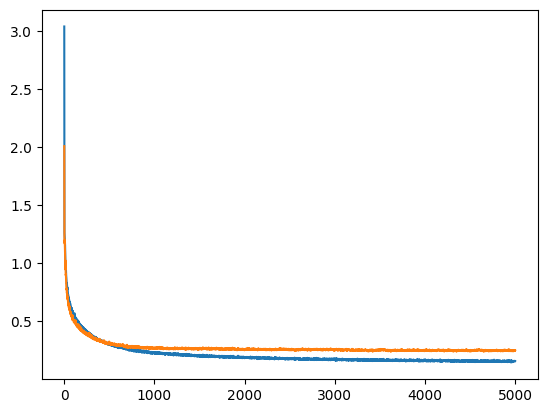

In [31]:
#Documents
#Logarithm
#No augmentation
#No keeping one sample together
# layers 8, 32, 64, 128, 256, 128, 64, 32, 8
#batch size = 100
#Bigger network (64 neurons max)
#lr=0.001
#dropout =0.02

plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.01

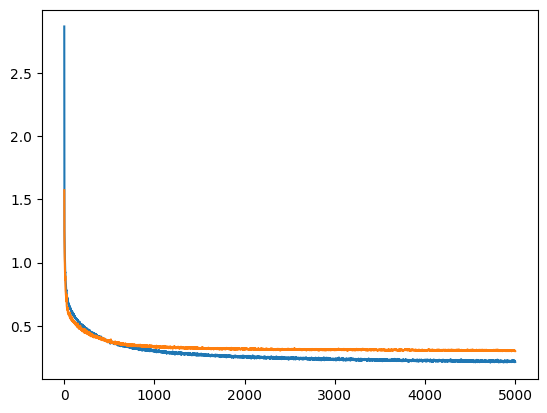

In [32]:
#Documents
#Logarithm
#No augmentation
#No keeping one sample together
# layers 8, 32, 64, 128, 64, 32, 8
#batch size = 100
#Bigger network (64 neurons max)
#lr=0.001
#dropout =0.02

plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.001

## Loading pretrained model

In [30]:
path = models_path[object_name]+'model_regression_' + '2024_09_28_23_53_51'

model = InksNet().to(device)
model.load_state_dict(torch.load(path))

/tmp/ipykernel_4142/2783579179.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path))


<All keys matched successfully>

## Prediction on test set

In [31]:
model.eval()
loss_fn = CustomLoss()

running_tloss = 0
for i, tdata in enumerate(test_loader):
    inputs, labels = tdata
    outputs = model(inputs)
    loss = loss_fn(outputs, labels)
    if i==0:
        out = outputs
        lab = labels
        res = abs(outputs-labels)
    else:
        res = torch.concat((res, abs(outputs-labels)), axis=0)
        lab = torch.concat((lab, labels), axis=0)
        out = torch.concat((out, outputs), axis=0)
    running_tloss += loss.item()
    
mean_loss = running_tloss/len(test_loader)

Consecutive inks from test set are in lab tensor (484 examples, 8 elements/coordinates):

In [32]:
lab

tensor([[ 0.6814, -3.8429, -7.3168,  ..., -2.0901, -5.5168, -0.8327],
        [ 1.7116, -4.4546, -7.4808,  ..., -1.2107, -5.7975, -1.4870],
        [ 1.7433, -3.2536, -7.8672,  ..., -4.1254, -3.4859, -2.4003],
        ...,
        [ 1.5180, -2.1008, -6.8141,  ..., -3.6722, -4.1360,  0.2913],
        [-0.0894, -3.8682, -7.6653,  ..., -1.7766, -5.5490, -0.9989],
        [-0.3599, -5.9045, -7.8310,  ...,  1.1395, -2.5659, -0.6577]],
       device='cuda:0')

Predictions are in out tensor (484 examples, 8 elements/coordinates):

In [33]:
out

tensor([[ 0.9690, -3.3788, -7.1624,  ..., -1.4181, -5.2635, -0.3372],
        [ 1.7105, -4.3192, -7.6652,  ..., -1.2601, -5.7997, -1.3739],
        [ 1.5090, -3.3608, -7.9812,  ..., -4.2639, -3.3761, -2.6388],
        ...,
        [ 0.4863, -3.6761, -8.2710,  ..., -3.2675, -3.2929,  1.0162],
        [-0.1427, -3.7380, -7.7630,  ..., -1.5468, -6.0373, -1.5448],
        [-0.3773, -5.6202, -7.2256,  ...,  1.0205, -2.6310, -0.7346]],
       device='cuda:0', grad_fn=<CatBackward0>)

Absolute value of difference between true values (lab) and prediction (out) are stored in res tensor (484 examples, 8 elements/coordinates):

In [34]:
res

tensor([[2.8762e-01, 4.6407e-01, 1.5433e-01,  ..., 6.7200e-01, 2.5331e-01,
         4.9546e-01],
        [1.1278e-03, 1.3542e-01, 1.8441e-01,  ..., 4.9436e-02, 2.1830e-03,
         1.1303e-01],
        [2.3428e-01, 1.0716e-01, 1.1399e-01,  ..., 1.3850e-01, 1.0977e-01,
         2.3852e-01],
        ...,
        [1.0317e+00, 1.5753e+00, 1.4569e+00,  ..., 4.0477e-01, 8.4307e-01,
         7.2490e-01],
        [5.3279e-02, 1.3016e-01, 9.7647e-02,  ..., 2.2972e-01, 4.8834e-01,
         5.4591e-01],
        [1.7363e-02, 2.8428e-01, 6.0535e-01,  ..., 1.1907e-01, 6.5158e-02,
         7.6925e-02]], device='cuda:0', grad_fn=<CatBackward0>)

To calculate mean error on consecutive coordinates run:

In [35]:
torch.mean(res, axis=0) 

tensor([0.1921, 0.2085, 0.3683, 0.1556, 0.1989, 0.1954, 0.2560, 0.2491],
       device='cuda:0', grad_fn=<MeanBackward1>)

Consecutive coordinates correspond to: Al, S, Cr, Mn, Co, Cu, Zn, Pb.

Significance of elements: Cu >> Mn > Al > Zn > Pb > S > Cr > Co >> all the others.

Later on we will modify loss function so that errors from coordinates will be weighted depending on the importance of chemical elements.

To calculate mean error on all coordinates run:

In [36]:
torch.mean(res)

tensor(0.2280, device='cuda:0', grad_fn=<MeanBackward0>)

## Saving the model

In [37]:
import time
ts = time.time()
import datetime
now = datetime.datetime.fromtimestamp(ts).strftime('%Y_%m_%d_%H_%M_%S')

torch.save(model.state_dict(), models_path[object_name]+'model_regression_'+now)

### Visualisations

In [38]:
dim_nr = 3
selected_outputs = out[:, dim_nr].cpu().detach().numpy()
selected_labels = lab[:, dim_nr].cpu().detach().numpy()

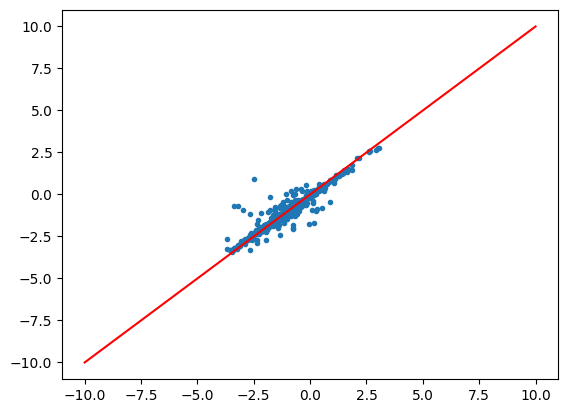

In [39]:
plt.plot(selected_labels, selected_outputs, '.')
plt.plot( [-10, 10],[-10, 10], 'red' )

## Quality of prediction: closest points

#### Creating df with means of classes

In [40]:
elements_names = [el.split('_')[0] for el in columns_to_keep_inds[object_name]]

In [41]:
train_val_df = pd.DataFrame(y_train.cpu())
train_val_df = pd.concat([train_val_df, 
                                    pd.DataFrame(y_val.cpu())])
train_val_df.columns = elements_names
train_val_df.insert(0, 'Sample_id', pd.concat([train_order, val_order]))
train_val_df.reset_index(drop=True, inplace=True)

In [42]:
mean_df = train_val_df[['Sample_id']]

for name in elements_names:
    mean_df[name] = train_val_df.groupby('Sample_id')[name].transform('mean')
    mean_df.drop_duplicates('Sample_id', inplace=True)
    
mean_df.sort_values(by='Sample_id', inplace=True)
mean_df.reset_index(drop=True, inplace=True)

/tmp/ipykernel_4142/649964028.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_df[name] = train_val_df.groupby('Sample_id')[name].transform('mean')
/tmp/ipykernel_4142/649964028.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_df.drop_duplicates('Sample_id', inplace=True)
/tmp/ipykernel_4142/649964028.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/i

#### Checking if there is any chance for it to work: if classes in y_test are close to means of classes in train_val set

In [43]:
y_test_df = pd.DataFrame(y_test.cpu())
y_test_df.columns = elements_names
y_test_df.insert(0, 'Sample_id', test_order)
y_test_df.reset_index(drop=True, inplace=True)

In [44]:
closest = []
for i in range(y_test_df.shape[0]):
    which_row = (abs(y_test_df.iloc[i, 1:] - mean_df.iloc[:,1:])).sum(1).idxmin()
    closest.append(mean_df.iloc[which_row]['Sample_id'])

In [45]:
len(closest)

780

In [46]:
y_test_df['Closest'] = closest

In [47]:
y_test_df[y_test_df['Sample_id'] == y_test_df['Closest']].shape[0] 

724

In [48]:
y_test_df[y_test_df['Sample_id'] == y_test_df['Closest']].shape[0] / len(closest)

0.9282051282051282

#### Now let's check if it works for the neural network's output.

In [49]:
model.eval()
outputs = model(X_test)

In [50]:
outputs_df = pd.DataFrame(outputs.cpu().detach().numpy())
outputs_df.columns = elements_names
outputs_df.insert(0, 'Real sample_id', test_order)
outputs_df.reset_index(drop=True, inplace=True)

In [51]:
closest = []
for i in range(outputs_df.shape[0]):
    which_row = (abs(outputs_df.iloc[i, 1:] - mean_df.iloc[:,1:])).sum(1).idxmin()
    closest.append(mean_df.iloc[which_row]['Sample_id'])

In [52]:
len(closest)

780

In [53]:
outputs_df['Closest'] = closest

In [54]:
outputs_df[y_test_df['Sample_id'] == outputs_df['Closest']].shape[0]

681

In [55]:
outputs_df[y_test_df['Sample_id'] == outputs_df['Closest']].shape[0] / len(closest)

0.8730769230769231

## Quality of prediction: confidence intervals

In [56]:
model.eval()
outputs = model(X_test)

In [57]:
elements_names = [el.split('_')[0] for el in columns_to_keep_inds[object_name]]

In [58]:
all_data_df = pd.DataFrame(y_train.cpu())
all_data_df = pd.concat([all_data_df, 
                        pd.DataFrame(y_val.cpu())])
all_data_df.columns = elements_names
all_data_df.insert(0, 'Sample_id', pd.concat([train_order, val_order]))
all_data_df.reset_index(drop=True, inplace=True)

In [59]:
min_max_df = all_data_df[['Sample_id']]

for name in elements_names:
    min_max_df[name + '_max'] = all_data_df.groupby('Sample_id')[name].transform('max')
    min_max_df.drop_duplicates('Sample_id', inplace=True)
    
for name in elements_names:
    min_max_df[name + '_min'] = all_data_df.groupby('Sample_id')[name].transform('min')
    min_max_df.drop_duplicates('Sample_id', inplace=True)
        
min_max_df.sort_values(by='Sample_id', inplace=True)
min_max_df.reset_index(drop=True, inplace=True)

max_df = min_max_df.iloc[:,1:(1+len(elements_names))]
max_df['Sample_id'] = min_max_df['Sample_id']
min_df = min_max_df.iloc[:,1+len(elements_names):]
min_df['Sample_id'] = min_max_df['Sample_id']

/tmp/ipykernel_4142/3264826654.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  min_max_df[name + '_max'] = all_data_df.groupby('Sample_id')[name].transform('max')
/tmp/ipykernel_4142/3264826654.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  min_max_df.drop_duplicates('Sample_id', inplace=True)
/tmp/ipykernel_4142/3264826654.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/sta

In [60]:
mean_sd_df = all_data_df[['Sample_id']]

for name in elements_names:
    mean_sd_df[name + '_mean'] = all_data_df.groupby('Sample_id')[name].transform('mean')
    mean_sd_df.drop_duplicates('Sample_id', inplace=True)
    
for name in elements_names:
    mean_sd_df[name + '_sd'] = all_data_df.groupby('Sample_id')[name].transform(np.std)
    mean_sd_df.drop_duplicates('Sample_id', inplace=True)
    
mean_sd_df.sort_values(by='Sample_id', inplace=True)
mean_sd_df.reset_index(drop=True, inplace=True)

upper_bound_df = mean_sd_df.iloc[:,1:(1+len(elements_names))].values + \
                2*mean_sd_df.iloc[:,1+len(elements_names):].values
upper_bound_df = pd.DataFrame(upper_bound_df, columns=elements_names)
upper_bound_df['Sample_id'] = mean_sd_df[['Sample_id']]

lower_bound_df = mean_sd_df.iloc[:,1:(1+len(elements_names))].values - \
                2*mean_sd_df.iloc[:,1+len(elements_names):].values
lower_bound_df = pd.DataFrame(lower_bound_df, columns=elements_names)
lower_bound_df['Sample_id'] = mean_sd_df[['Sample_id']]

/tmp/ipykernel_4142/2008320981.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_sd_df[name + '_mean'] = all_data_df.groupby('Sample_id')[name].transform('mean')
/tmp/ipykernel_4142/2008320981.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_sd_df.drop_duplicates('Sample_id', inplace=True)
/tmp/ipykernel_4142/2008320981.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/s

In [61]:
min_max_res_list = []
for test_example, sample_id in zip(outputs, test_order):
    
    greater_than_min = test_example.cpu().detach().numpy() > \
                    np.array(min_df.loc[min_df['Sample_id'] == sample_id, min_df.columns != 'Sample_id'])
    
    less_than_max = test_example.cpu().detach().numpy() < \
                    np.array(max_df.loc[max_df['Sample_id'] == sample_id, max_df.columns != 'Sample_id'])
    
    res = np.logical_and(greater_than_min, less_than_max)
    
    #print(res)
    min_max_res_list.append(res)

In [62]:
sd_res_list = []
for test_example, sample_id in zip(outputs, test_order):
    
    greater = test_example.cpu().detach().numpy() > \
    np.array(lower_bound_df.loc[lower_bound_df['Sample_id'] == sample_id, lower_bound_df.columns != 'Sample_id'])
    
    less = test_example.cpu().detach().numpy() < \
    np.array(upper_bound_df.loc[upper_bound_df['Sample_id'] == sample_id, upper_bound_df.columns != 'Sample_id'])
    
    res = np.logical_and(greater, less)
    
    #print(res)
    sd_res_list.append(res)

In [63]:
elements_names

['Al', 'S', 'Cr', 'Mn', 'Co', 'Cu', 'Zn', 'Pb']

Percentage of points inside mean +- 2 standard deviations interval:

In [64]:
np.array(sd_res_list).mean()

0.8391025641025641

On consecutive coordinates:

In [65]:
np.array(sd_res_list).mean(0)

array([[0.88205128, 0.86410256, 0.89871795, 0.79358974, 0.82051282,
        0.79102564, 0.85769231, 0.80512821]])

Percentage of points inside min-max interval:

In [66]:
np.array(min_max_res_list).mean()

0.7737179487179487

On consecutive coordinates:

In [67]:
np.array(min_max_res_list).mean(0)

array([[0.80128205, 0.83974359, 0.85384615, 0.69615385, 0.73717949,
        0.72820513, 0.78589744, 0.7474359 ]])

### Visualisations of mean +- 2 * standard deviation intervals

In [68]:
outputs_df

,Real sample_id,Al,S,Cr,Mn,Co,Cu,Zn,Pb,Closest
0,199,0.969035,-3.378817,-7.162446,-1.179811,-2.314258,-1.418057,-5.263530,-0.337243,199.0
1,116,1.710483,-4.319156,-7.665235,-1.451507,-4.616229,-1.260126,-5.799705,-1.373924,116.0
2,211,1.509022,-3.360779,-7.981229,-1.243133,-3.514232,-4.263885,-3.376094,-2.638793,211.0
3,25,1.510858,-3.933841,-6.116460,-1.852213,-4.688020,-2.238863,-4.841711,-2.213950,25.0
4,37,2.537949,-2.125573,-6.530601,-0.308427,-4.993161,-2.814723,-4.334805,-0.169225,37.0
...,...,...,...,...,...,...,...,...,...,...
775,226,0.612451,-4.633138,-8.640785,-0.396364,-4.019146,-2.683430,-4.020689,0.667880,226.0
776,210,1.233591,-2.413034,-7.280320,-1.106729,-4.699419,-4.096749,-5.086503,-1.701186,210.0
777,61,0.486289,-3.676109,-8.271021,-0.762351,-3.267653,-3.267457,-3.292926,1.016193,226.0
778,197,-0.142725,-3.738025,-7.762990,-1.530186,-2.351414,-1.546841,-6.037303,-1.544798,198.0


In [69]:
min_max_df.shape

(260, 17)

In [70]:
outputs_df.columns

Index(['Real sample_id', 'Al', 'S', 'Cr', 'Mn', 'Co', 'Cu', 'Zn', 'Pb',
       'Closest'],
      dtype='object')

IndexError: index 2 is out of bounds for axis 0 with size 2

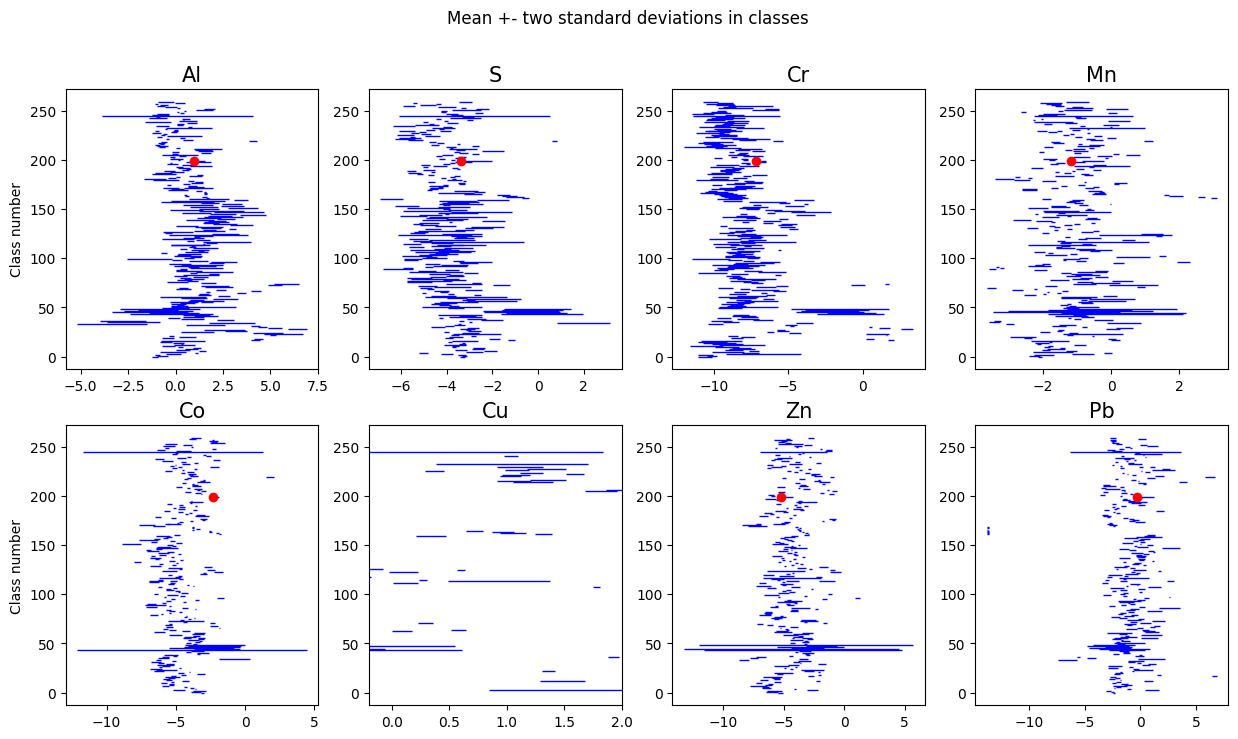

In [73]:
fig, ax = plt.subplots(2,4, figsize=(15,8))
plt.suptitle('Mean +- two standard deviations in classes')
for sample_id in range(min_max_df.shape[0]):
    for element in range(int((min_max_df.shape[1]-1)/2)):
        ax[element//4][element%4].hlines(y=sample_id, xmin=lower_bound_df.iloc[sample_id, element], 
                  xmax=upper_bound_df.iloc[sample_id, element], 
                  color="blue", linewidth=1)
        ax[element//4][element%4].set_title(elements_names[element], size=15)
        if element == 5:
            ax[element//4][element%4].set_xlim([-0.2, 2.0])
        if element == 0 or element == 4:
            ax[element//4][element%4].set_ylabel('Class number')
            
for row in range(outputs_df.shape[0]):
    for el_nr, element in enumerate(outputs_df.columns[1:]):
        ax[el_nr//4][el_nr%4].plot(outputs_df[element][row], outputs_df['Real sample_id'][row], 'ro')
    
#plt.savefig(figures_path + 'intervals.png', dpi=300)

### Visualisations of min-max intervals

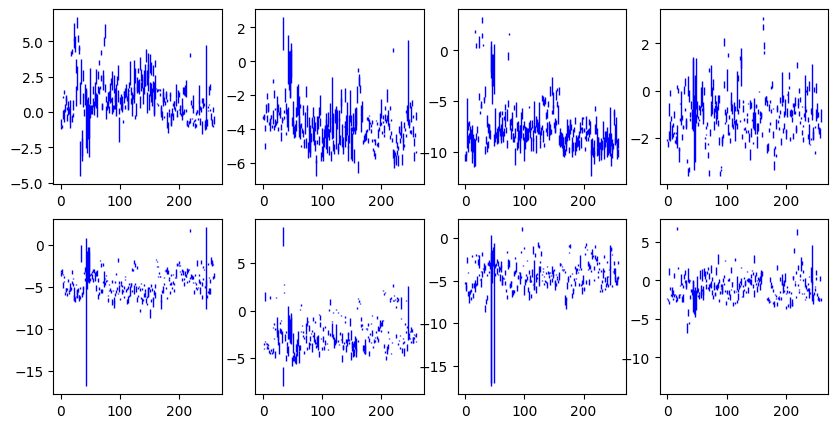

In [68]:
fig, ax = plt.subplots(2,4, figsize=(10,5))
for sample_id in range(min_max_df.shape[0]):
    for element in range(int((min_max_df.shape[1]-1)/2)):
        ax[element//4][element%4].vlines(x=sample_id, ymin=min_max_df.iloc[sample_id, element+9], 
                  ymax=min_max_df.iloc[sample_id, element+1], 
                  color="blue", linewidth=1)
        #ax[element%4][element%2].set_title(elements_names[element])

For a single element:

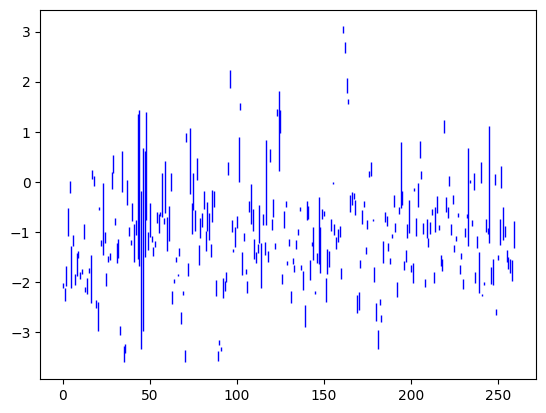

In [69]:
element = 3
for sample_id in range(min_max_df.shape[0]):
    plt.vlines(x=sample_id, ymin=min_max_df.iloc[sample_id, element+9], 
                  ymax=min_max_df.iloc[sample_id, element+1], 
                  color="blue", linewidth=1)

## Interpretability